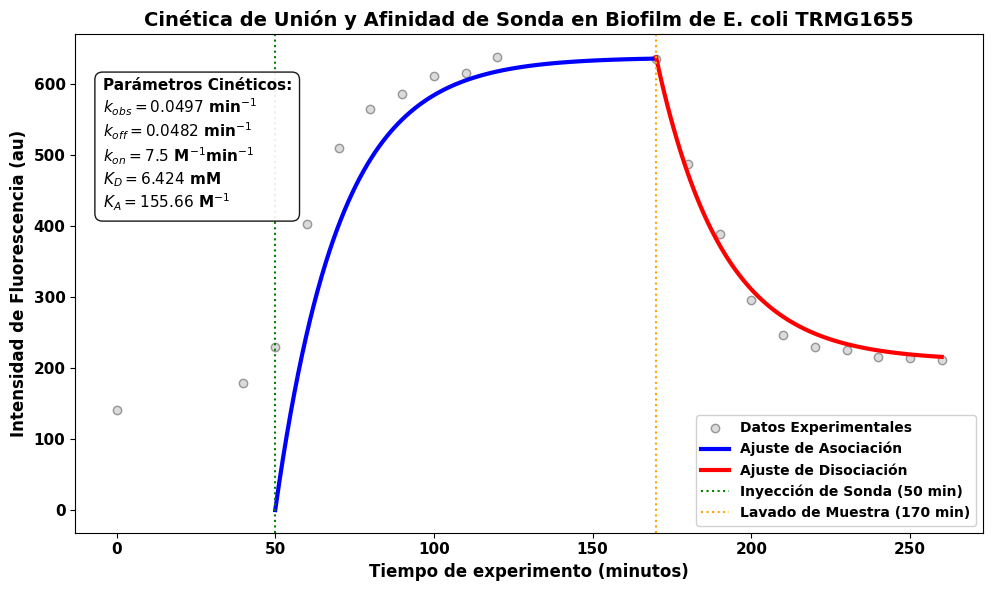

In [ ]:
# ==============================================================================
# SCRIPT 4: Generación de la Figura Maestra Cinética
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el archivo original completo
df = pd.read_excel('DatosEnCrudo.xlsx', header=None)

# Extraer el tiempo real y la fluorescencia (Réplica 1)
tiempo_real = df[7].dropna().values
fluorescencia = df[8].dropna().values

# ==========================================
# 2. TUS PARÁMETROS CORREGIDOS
# ==========================================
k_obs = 0.04968   # Promedio de asociación
k_off = 0.04818   # Promedio de disociación
Y_max = 637.0     # Pico máximo
Fondo = 210.0     # Línea base residual

# Parámetros recalculados con [L] = 200 uM (0.0002 M)
k_on = 7.5        # M^-1 min^-1
Kd_mM = 6.424     # mM (milimolar)
Ka = 155.66       # M^-1 (Constante de Asociación)

# Tiempos clave
t_inyeccion = 50
t_lavado = 170

# ==========================================
# 3. CONSTRUCCIÓN DE LAS CURVAS TEÓRICAS
# ==========================================
t_asoc_real = np.linspace(t_inyeccion, t_lavado, 100)
t_asoc_ajustado = t_asoc_real - t_inyeccion
curva_asoc = Y_max * (1 - np.exp(-k_obs * t_asoc_ajustado))

t_disoc_real = np.linspace(t_lavado, max(tiempo_real), 100)
t_disoc_ajustado = t_disoc_real - t_lavado
curva_disoc = (Y_max - Fondo) * np.exp(-k_off * t_disoc_ajustado) + Fondo

# ==========================================
# 4. GRAFICAR TODO JUNTO (FIGURA MAESTRA)
# ==========================================
plt.figure(figsize=(10, 6))

# Puntos reales
plt.scatter(tiempo_real, fluorescencia, color='lightgray', edgecolors='gray',
            label='Datos Experimentales', zorder=1, alpha=0.8)

# Curvas matemáticas
plt.plot(t_asoc_real, curva_asoc, color='blue', linewidth=3, label='Ajuste de Asociación')
plt.plot(t_disoc_real, curva_disoc, color='red', linewidth=3, label='Ajuste de Disociación')

# Líneas de eventos
plt.axvline(x=t_inyeccion, color='green', linestyle=':', label='Inyección de Sonda (50 min)')
plt.axvline(x=t_lavado, color='orange', linestyle=':', label='Lavado de Muestra (170 min)')

# --- CUADRO DE TEXTO CORREGIDO ---
texto_resultados = (
    f"Parámetros Cinéticos:\n"
    f"$k_{{obs}} = {k_obs:.4f}$ min$^{{-1}}$\n"
    f"$k_{{off}} = {k_off:.4f}$ min$^{{-1}}$\n"
    f"$k_{{on}} = {k_on:.1f}$ M$^{{-1}}$min$^{{-1}}$\n"
    f"$K_D = {Kd_mM:.3f}$ mM\n"
    f"$K_A = {Ka:.2f}$ M$^{{-1}}$"
)

plt.text(0.03, 0.65, texto_resultados, transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

# Estética
plt.title('Cinética de Unión y Afinidad de Sonda en Biofilm de E. coli TRMG1655', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de experimento (minutos)', fontsize=12)
plt.ylabel('Intensidad de Fluorescencia (au)', fontsize=12)
plt.legend(loc='lower right', framealpha=0.9)
plt.grid(False)
plt.tight_layout()
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.xticks(fontweight='bold', fontsize=11)
plt.yticks(fontweight='bold', fontsize=11)
plt.show()